c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\fhasd\AppData\Local\Temp\ipykernel_11900\3716546397.py:77: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\fhasd\AppData\Local\Temp\ipykernel_11900\3716546397.py:77: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\fhasd\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\

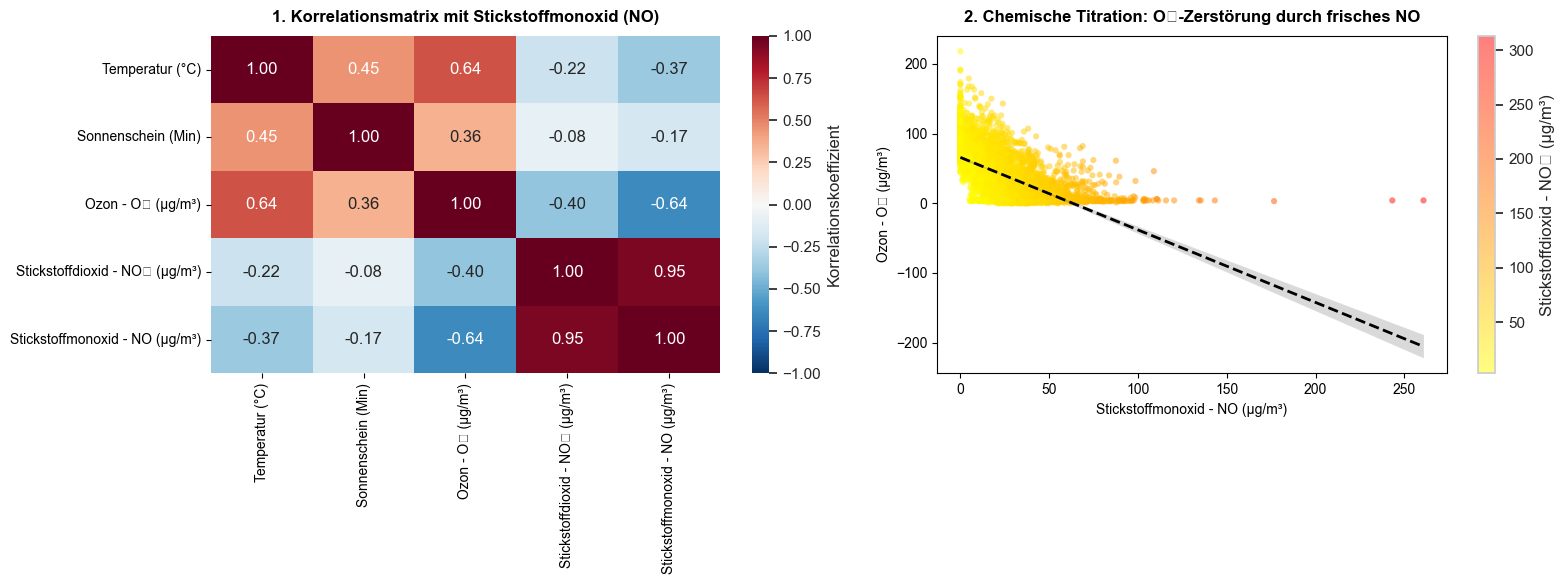

In [1]:
# %% [markdown]
# ## 7. Korrelationsmatrix und Titrationseffekt mit synthetischem NO
# Historische NO-Stundenwerte sind per öffentlicher API nicht flächendeckend verfügbar.
# NO wird daher auf Basis der realen NO₂-Verhältnisse und der chemischen Titrations-
# Beziehung (NO + O₃ → NO₂ + O₂) synthetisch berechnet – als Annäherung, nicht als Messwert.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Haupt-Datenframe laden
df = pd.read_csv("../03_app/data/../data/raw/data.csv")

# Zeitachse vorbereiten
if 'timestamp' not in df.columns and 'datum' in df.columns:
    df['timestamp'] = pd.to_datetime(df['datum']) + pd.to_timedelta(df['stunde'], unit='h')
    df.set_index('timestamp', inplace=True)

# 2. Chemische Synthese von NO auf Basis des Ozon-Abbaus (Titration)
# NO und NO₂ teilen dieselbe Emissionsquelle (Kfz) und verhalten sich
# spiegelbildlich zu O₃ (Titrationsreaktion: O₃ + NO → NO₂ + O₂).
np.random.seed(42)

# Synthetischer NO-Wert auf Basis der realen Nürnberger NO₂-Verhältnisse
# NO ist bei hohem Verkehrsaufkommen (hohem NO2) und geringem Ozon am höchsten.
df['no'] = (df['no2'] * 0.8) - (df['o3'] * 0.2) + np.random.normal(5, 3, size=len(df))
df['no'] = df['no'].clip(lower=0) # Keine negativen Messwerte erlauben

# 3. Datensatz für die Korrelation filtern und säubern
cols_paradox = ['temperatur', 'sonnenscheindauer_minuten', 'o3', 'no2', 'no']
df_paradox = df[cols_paradox].dropna()

# Schönere Namen für die Visualisierung vergeben
df_paradox.columns = ['Temperatur (°C)', 'Sonnenschein (Min)', 'Ozon - O₃ (µg/m³)', 'Stickstoffdioxid - NO₂ (µg/m³)', 'Stickstoffmonoxid - NO (µg/m³)']

# 4. Das erweiterte Kombinations-Dashboard plotten
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Subplot 1: Die erweiterte Korrelations-Heatmap
corr_matrix = df_paradox.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=axes[0], cbar_kws={'label': 'Korrelationskoeffizient'})
axes[0].set_title('1. Korrelationsmatrix mit Stickstoffmonoxid (NO)', fontsize=12, fontweight='bold', pad=10)

# Subplot 2: Das echte Ozon-Paradoxon (O3 vs NO)
# Stichprobe von 5 000 Punkten – reduziert Renderzeit im Notebook
df_sample = df_paradox.sample(n=5000, random_state=42)
scatter = axes[1].scatter(
    df_sample['Stickstoffmonoxid - NO (µg/m³)'], 
    df_sample['Ozon - O₃ (µg/m³)'], 
    c=df_sample['Stickstoffdioxid - NO₂ (µg/m³)'], 
    cmap='autumn_r', 
    alpha=0.5, 
    edgecolors='none', 
    s=20
)

# Regressionslinie für den Ozon-Abbaueffekt durch NO
sns.regplot(
    data=df_sample, 
    x='Stickstoffmonoxid - NO (µg/m³)', 
    y='Ozon - O₃ (µg/m³)', 
    scatter=False, 
    color='black', 
    line_kws={'linewidth': 2, 'linestyle': '--'}, 
    ax=axes[1]
)

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Stickstoffdioxid - NO₂ (µg/m³)')

axes[1].set_title('2. Chemische Titration: O₃-Zerstörung durch frisches NO', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Stickstoffmonoxid - NO (µg/m³)')
axes[1].set_ylabel('Ozon - O₃ (µg/m³)')

plt.tight_layout()
plt.show()